# Prédiction des retards de vols américains

Ce notebook regroupe tout le projet dans un parcours unique, lisible et exécutable de haut en bas.

1. **Parsing avec PySpark** sur 10 000 vols ;
2. **Analyse avec PySpark** et corrélations ;
3. **Machine learning avec Python**, Polars et CatBoost ;
4. **Visualisation et prédiction** directement dans Jupyter.

> La cause liée à l'avion précédent est exclue dès le dataset propre. Elle n'est utilisée ni dans l'analyse, ni dans le machine learning, ni dans les prédictions.

> **Objectif métier :** au moins 50 % de précision parmi les alertes, au moins 20 % des retards détectés et seulement 5 à 10 % des vols signalés. Si ces trois contraintes ne sont pas respectées, le modèle reste expérimental et aucune alerte n'est déclarée publiable.

## Mode d'emploi

Exécuter les cellules dans l'ordre avec **Run → Run All Cells**. La configuration actuelle évalue le modèle officiel sur 10 % du CSV complet, soit environ 696 000 vols exploitables. Si l'artefact v5 n'existe pas, il est réentraîné automatiquement.

Pour revenir à une démonstration rapide sur le CSV versionné, définir `USE_FULL_ML_DATA = False`. Le CSV complet reste traité exclusivement en Python et ne passe jamais par Spark.

Les sorties Parquet, les résultats d'analyse et les modèles sont régénérables et ignorés par Git. Le seuil de décision est choisi uniquement sur la validation ; novembre et décembre restent le test temporel.

In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

project_root = Path.cwd().resolve()
while project_root != project_root.parent and not (project_root / "pyproject.toml").exists():
    project_root = project_root.parent
if not (project_root / "pyproject.toml").exists():
    raise FileNotFoundError("La racine du projet contenant pyproject.toml est introuvable.")

os.chdir(project_root)
os.environ.setdefault("SPARK_LOCAL_IP", "127.0.0.1")
os.environ.setdefault("PYSPARK_SUBMIT_ARGS", "--conf spark.ui.showConsoleProgress=false pyspark-shell")
source_path = project_root / "src"
if str(source_path) not in sys.path:
    sys.path.insert(0, str(source_path))

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", palette="deep")
print("Environnement du projet prêt.")

Environnement du projet prêt.


In [2]:
SEED = 42
SPARK_SAMPLE_SIZE = 10_000
SPARK_INPUT_PATH = project_root / "data/flight_data_2024_sample.csv"
SPARK_OUTPUT_PATH = project_root / "data/processed/spark/flights_10000"
ANALYSIS_OUTPUT_PATH = project_root / "data/analysis/spark"

# False : démonstration rapide sur 10 000 lignes. True : 10 % du CSV complet.
USE_FULL_ML_DATA = True
# True réentraîne le modèle ; False recharge l'artefact v5 s'il existe.
RETRAIN_MODEL = False

full_ml_path = project_root / "data/flight_data_2024.csv"
if USE_FULL_ML_DATA and not full_ml_path.exists():
    raise FileNotFoundError("Le CSV complet doit être placé dans data/flight_data_2024.csv.")

ML_INPUT_PATH = full_ml_path if USE_FULL_ML_DATA else SPARK_INPUT_PATH
ML_SAMPLE_FRACTION = 0.1 if USE_FULL_ML_DATA else 1.0
model_suffix = "official" if USE_FULL_ML_DATA else "notebook_demo"
MODEL_PATH = project_root / f"models/{model_suffix}/flight_delay_models.joblib"
METRICS_PATH = project_root / f"models/{model_suffix}/training_metrics.json"
IMPORTANCE_PATH = project_root / f"models/{model_suffix}/feature_importance.csv"

configuration = pd.DataFrame(
    {
        "Paramètre": [
            "Lignes Spark",
            "Graine",
            "CSV Spark",
            "CSV ML",
            "Fraction ML",
            "Réentraîner",
            "Précision minimale des alertes",
            "Rappel minimal",
            "Couverture d'alertes attendue",
        ],
        "Valeur": [
            SPARK_SAMPLE_SIZE,
            SEED,
            str(SPARK_INPUT_PATH.relative_to(project_root)),
            str(ML_INPUT_PATH.relative_to(project_root)),
            ML_SAMPLE_FRACTION,
            RETRAIN_MODEL,
            "50 %",
            "20 %",
            "5 à 10 %",
        ],
    }
)
display(configuration)

,Paramètre,Valeur
0,Lignes Spark,10000
1,Graine,42
2,CSV Spark,data/flight_data_2024_sample.csv
3,CSV ML,data/flight_data_2024.csv
4,Fraction ML,0.1
5,Réentraîner,False
6,Précision minimale des alertes,50 %
7,Rappel minimal,20 %
8,Couverture d'alertes attendue,5 à 10 %


# Étape 1 — Parsing avec PySpark

Spark lit le CSV avec un schéma textuel explicite. Les 10 000 lignes sont ensuite typées, contrôlées et séparées entre lignes valides et quarantaine. Le résultat propre est écrit en Parquet.

In [3]:
from flight_delays.parsing import (
    create_spark_session,
    parse_and_validate,
    read_flights_csv,
    sample_rows,
    split_rows,
    write_results,
)

spark = create_spark_session(
    application_name="Notebook des retards de vols",
    master="local[2]",
)
spark.sparkContext.setLogLevel("ERROR")

raw_data = read_flights_csv(spark, str(SPARK_INPUT_PATH))
raw_preview_columns = [
    "fl_date",
    "op_unique_carrier",
    "op_carrier_fl_num",
    "origin",
    "dest",
    "crs_dep_time",
    "crs_arr_time",
    "arr_delay",
]
print(f"Lignes disponibles dans le CSV Spark : {raw_data.count():,}")
display(raw_data.select(*raw_preview_columns).limit(10).toPandas())

visible_schema = pd.DataFrame(
    [
        {"Colonne": field.name, "Type brut": field.dataType.simpleString()}
        for field in raw_data.schema.fields
        if field.name not in {"late_aircraft_delay", "_corrupt_record"}
    ]
)
display(visible_schema)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/17 17:11:54 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Lignes disponibles dans le CSV Spark : 10,000


,fl_date,op_unique_carrier,op_carrier_fl_num,origin,dest,crs_dep_time,crs_arr_time,arr_delay
0,2024-04-18,MQ,3535.0,DFW,RAP,1018,1149,-10.0
1,2024-01-01,AA,148.0,CLT,PHX,1637,1923,-17.0
2,2024-12-12,9E,5440.0,CHA,ATL,1000,1059,-17.0
3,2024-04-08,WN,1971.0,OMA,LAS,1330,1430,1.0
4,2024-02-16,WN,862.0,BWI,MYR,1340,1510,-1.0
5,2024-04-15,WN,2358.0,SAN,PHX,715,830,-14.0
6,2024-11-27,G4,163.0,MLB,ABE,933,1202,-4.0
7,2024-08-31,AS,1269.0,BNA,PDX,1855,2155,-27.0
8,2024-04-19,OO,3438.0,LAX,SJC,820,939,-2.0
9,2024-02-08,OO,5654.0,SFO,BFL,2235,2350,-23.0


,Colonne,Type brut
0,year,string
1,month,string
2,day_of_month,string
3,day_of_week,string
4,fl_date,string
5,op_unique_carrier,string
6,op_carrier_fl_num,string
7,origin,string
8,origin_city_name,string
9,origin_state_nm,string


In [4]:
sampled_data = sample_rows(raw_data, sample_size=SPARK_SAMPLE_SIZE, seed=SEED).cache()
validated_data = parse_and_validate(sampled_data).cache()
valid_rows, rejected_rows = split_rows(validated_data)
valid_count = valid_rows.count()
rejected_count = rejected_rows.count()

quality_summary = pd.DataFrame(
    {
        "Statut": ["Lignes valides", "Lignes rejetées", "Total"],
        "Nombre": [valid_count, rejected_count, valid_count + rejected_count],
    }
)
display(quality_summary)

assert valid_count == SPARK_SAMPLE_SIZE
assert "late_aircraft_delay" not in validated_data.columns

clean_preview_columns = [
    "fl_date",
    "op_unique_carrier",
    "op_carrier_fl_num",
    "origin",
    "dest",
    "scheduled_departure_minutes",
    "scheduled_arrival_minutes",
    "arr_delay",
]
display(valid_rows.select(*clean_preview_columns).limit(15).toPandas())

,Statut,Nombre
0,Lignes valides,10000
1,Lignes rejetées,0
2,Total,10000


,fl_date,op_unique_carrier,op_carrier_fl_num,origin,dest,scheduled_departure_minutes,scheduled_arrival_minutes,arr_delay
0,2024-09-12,YX,4453,JFK,RDU,930,1041,3.0
1,2024-03-08,AA,299,STT,JFK,759,960,-19.0
2,2024-05-30,WN,5232,LGA,DEN,360,505,-6.0
3,2024-04-16,NK,1376,TPA,BOS,554,734,-2.0
4,2024-09-21,F9,4966,LAS,CLE,1380,373,-7.0
5,2024-06-28,OO,3371,SAN,STS,1221,1329,4.0
6,2024-03-22,WN,2935,SLC,OAK,800,850,-3.0
7,2024-12-26,DL,813,PHX,DTW,960,1295,-1.0
8,2024-04-11,MQ,3793,CHA,DFW,992,1077,8.0
9,2024-03-06,UA,2013,MCO,SFO,1100,1294,19.0


In [5]:
written_valid_count, written_rejected_count = write_results(
    validated_data,
    str(SPARK_OUTPUT_PATH),
    mode="overwrite",
)
sampled_data.unpersist()
print(
    f"Parquet créé : {written_valid_count:,} lignes valides et "
    f"{written_rejected_count:,} lignes rejetées dans "
    f"{SPARK_OUTPUT_PATH.relative_to(project_root)}."
)

Parquet créé : 10,000 lignes valides et 0 lignes rejetées dans data/processed/spark/flights_10000.


# Étape 2 — Analyse avec PySpark

Toutes les statistiques ci-dessous sont calculées avec Spark sur le Parquet propre : indicateurs globaux, valeurs manquantes, mois, compagnies, aéroports, causes et corrélations de Pearson. Seuls les petits résultats agrégés sont convertis en pandas pour être affichés facilement.

In [6]:
from flight_delays.analysis import (
    CORRELATION_COLUMNS,
    add_flight_status,
    load_spark_data,
    write_analysis,
)

clean_spark_data = load_spark_data(spark, str(SPARK_OUTPUT_PATH / "flights")).cache()
overview_spark, arrival_correlations_spark, correlation_row_count = write_analysis(
    clean_spark_data,
    str(ANALYSIS_OUTPUT_PATH),
    mode="overwrite",
)

def read_spark_csv_output(relative_path: str) -> pd.DataFrame:
    output_directory = ANALYSIS_OUTPUT_PATH / relative_path
    part_files = sorted(output_directory.glob("part-*.csv"))
    if not part_files:
        raise FileNotFoundError(f"Aucun résultat CSV trouvé dans {output_directory}.")
    return pd.read_csv(part_files[0])

overview_frame = overview_spark.toPandas()
arrival_correlations = arrival_correlations_spark.toPandas()
status_metrics = read_spark_csv_output("flight_status")
missing_values = read_spark_csv_output("missing_values")
monthly_metrics = read_spark_csv_output("monthly_metrics")
carrier_metrics = read_spark_csv_output("carrier_metrics")
origin_metrics = read_spark_csv_output("origin_metrics")
delay_causes = read_spark_csv_output("delay_causes")
correlation_matrix_long = read_spark_csv_output("correlations/matrix")

print(f"Analyse Spark terminée ; {correlation_row_count:,} vols utilisés pour les corrélations.")

Analyse Spark terminée ; 9,836 vols utilisés pour les corrélations.


In [7]:
overview = overview_frame.iloc[0]
key_indicators = pd.DataFrame(
    {
        "Indicateur": [
            "Vols analysés",
            "Vols achevés",
            "Retards ≥ 15 minutes",
            "Taux de retard parmi les vols achevés",
            "Vols annulés",
            "Vols déroutés",
            "Retard moyen à l'arrivée",
            "Retard médian à l'arrivée",
        ],
        "Valeur": [
            f"{int(overview['flight_count']):,}",
            f"{int(overview['completed_flight_count']):,}",
            f"{int(overview['delayed_flight_count']):,}",
            f"{overview['delayed_flight_percentage']:.1f} %",
            f"{int(overview['cancelled_flight_count']):,}",
            f"{int(overview['diverted_flight_count']):,}",
            f"{overview['average_arrival_delay_minutes']:.1f} min",
            f"{overview['median_arrival_delay_minutes']:.0f} min",
        ],
    }
)
display(key_indicators)
display(Markdown("### Statuts des vols"), status_metrics)
display(Markdown("### Valeurs manquantes"), missing_values.query("missing_count > 0").head(15))
display(Markdown("### Quatre causes retenues"), delay_causes)
display(Markdown("### Corrélations avec le retard à l'arrivée"), arrival_correlations)

,Indicateur,Valeur
0,Vols analysés,"10,000"
1,Vols achevés,"9,836"
2,Retards ≥ 15 minutes,"2,119"
3,Taux de retard parmi les vols achevés,21.5 %
4,Vols annulés,122
5,Vols déroutés,42
6,Retard moyen à l'arrivée,7.5 min
7,Retard médian à l'arrivée,-6 min


### Statuts des vols

,flight_status,flight_count,flight_percentage
0,on_time,7717,77.17
1,delayed_15_plus,2119,21.19
2,cancelled,122,1.22
3,diverted,42,0.42


### Valeurs manquantes

,column,missing_count,missing_percentage
0,cancellation_code,9878,98.78
1,actual_elapsed_time,164,1.64
2,air_time,164,1.64
3,arr_delay,164,1.64
4,arr_time,127,1.27
5,taxi_in,127,1.27
6,wheels_on,127,1.27
7,taxi_out,120,1.20
8,wheels_off,120,1.20
9,dep_delay,116,1.16


### Quatre causes retenues

,cause,total_delay_minutes,affected_flight_count,delay_minutes_percentage
0,carrier_delay,48709,1136,54.181915
1,nas_delay,30271,1056,33.672232
2,weather_delay,10831,141,12.047965
3,security_delay,88,6,0.097888


### Corrélations avec le retard à l'arrivée

,variable,correlation,absolute_correlation,available_before_departure
0,dep_delay,0.966336,0.966336,False
1,carrier_delay,0.657717,0.657717,False
2,nas_delay,0.355320,0.355320,False
3,weather_delay,0.317030,0.317030,False
4,taxi_out,0.184382,0.184382,False
5,taxi_in,0.130079,0.130079,False
6,scheduled_departure_minutes,0.087305,0.087305,True
7,scheduled_arrival_minutes,0.075227,0.075227,True
8,actual_elapsed_time,0.048491,0.048491,False
9,day_of_week,0.036520,0.036520,True


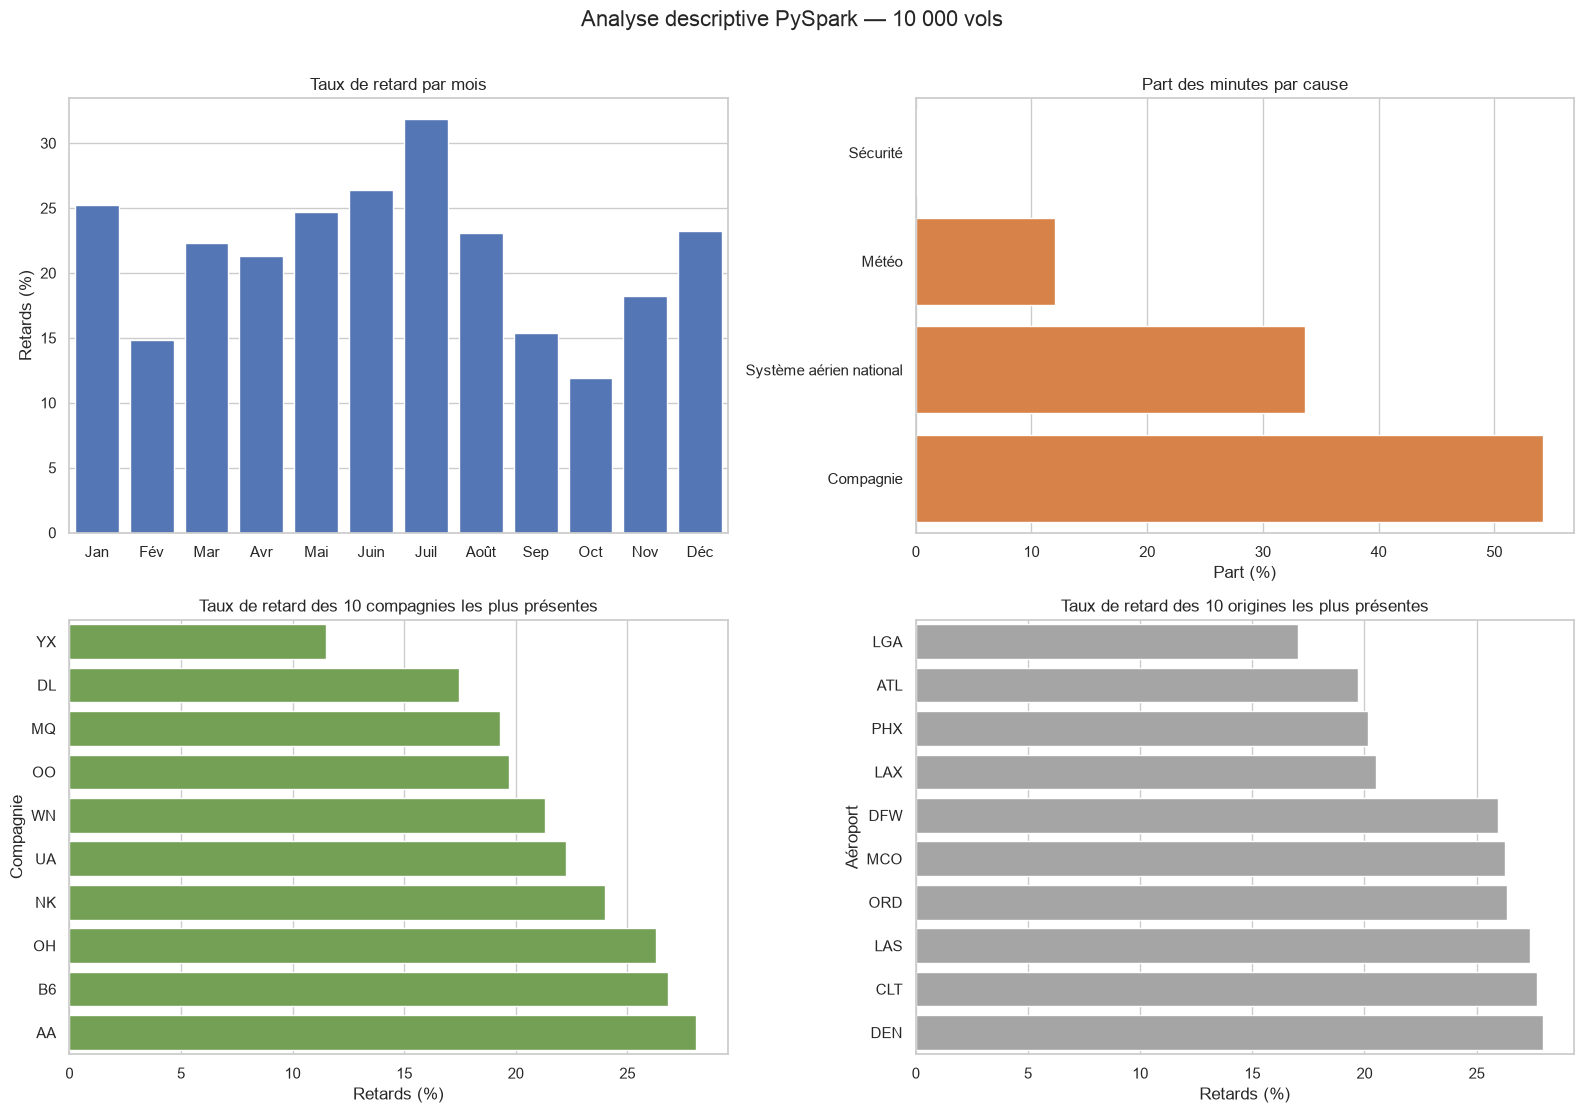

In [8]:
month_labels = {
    1: "Jan", 2: "Fév", 3: "Mar", 4: "Avr",
    5: "Mai", 6: "Juin", 7: "Juil", 8: "Août",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Déc",
}
monthly_plot = monthly_metrics.sort_values("month").copy()
monthly_plot["Mois"] = monthly_plot["month"].map(month_labels)

figure, axes = plt.subplots(2, 2, figsize=(16, 11))
sns.barplot(data=monthly_plot, x="Mois", y="delayed_flight_percentage", ax=axes[0, 0], color="#4472C4")
axes[0, 0].set(title="Taux de retard par mois", xlabel="", ylabel="Retards (%)")

cause_labels = {
    "carrier_delay": "Compagnie",
    "weather_delay": "Météo",
    "nas_delay": "Système aérien national",
    "security_delay": "Sécurité",
}
cause_plot = delay_causes.sort_values("delay_minutes_percentage", ascending=True).copy()
cause_plot["Cause"] = cause_plot["cause"].map(cause_labels)
sns.barplot(data=cause_plot, y="Cause", x="delay_minutes_percentage", ax=axes[0, 1], color="#ED7D31")
axes[0, 1].set(title="Part des minutes par cause", xlabel="Part (%)", ylabel="")

top_carriers = carrier_metrics.nlargest(10, "flight_count").sort_values("delayed_flight_percentage")
sns.barplot(data=top_carriers, y="op_unique_carrier", x="delayed_flight_percentage", ax=axes[1, 0], color="#70AD47")
axes[1, 0].set(title="Taux de retard des 10 compagnies les plus présentes", xlabel="Retards (%)", ylabel="Compagnie")

top_origins = origin_metrics.nlargest(10, "flight_count").sort_values("delayed_flight_percentage")
sns.barplot(data=top_origins, y="origin", x="delayed_flight_percentage", ax=axes[1, 1], color="#A5A5A5")
axes[1, 1].set(title="Taux de retard des 10 origines les plus présentes", xlabel="Retards (%)", ylabel="Aéroport")

figure.suptitle("Analyse descriptive PySpark — 10 000 vols", fontsize=16, y=1.01)
figure.tight_layout()
plt.show()

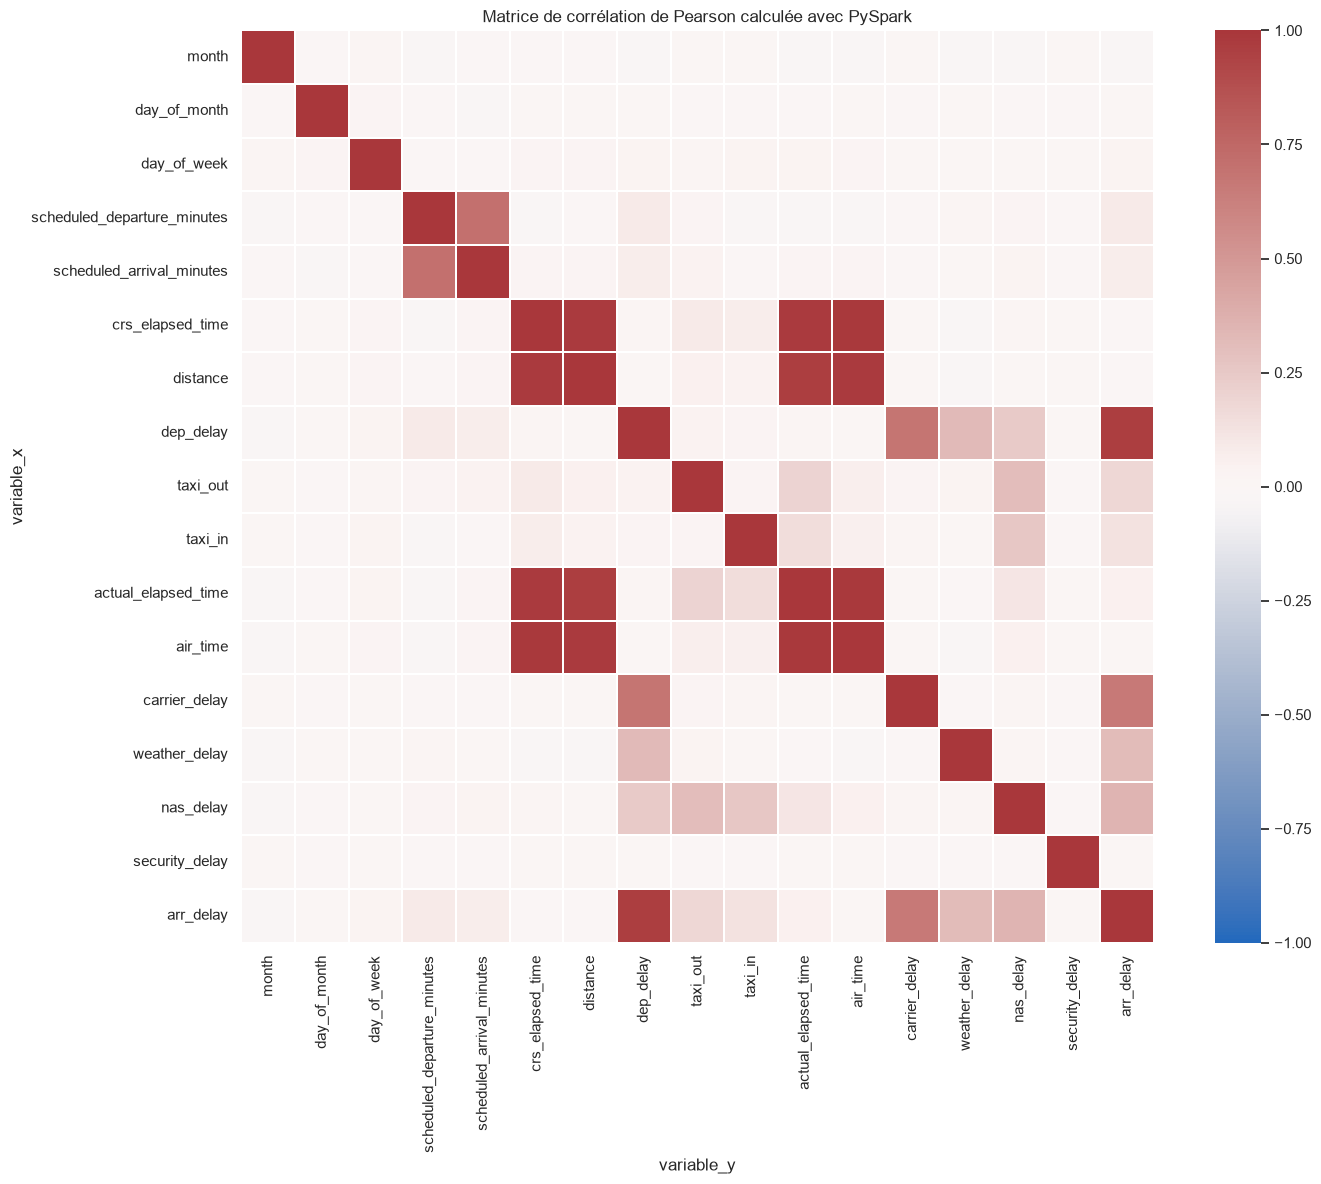

**Attention :** `dep_delay` et les colonnes de causes sont connues après le départ. Elles expliquent le passé mais constitueraient une fuite de données pour une prédiction avant le vol.

In [9]:
correlation_matrix = (
    correlation_matrix_long
    .pivot(index="variable_x", columns="variable_y", values="correlation")
    .loc[CORRELATION_COLUMNS, CORRELATION_COLUMNS]
)
plt.figure(figsize=(15, 12))
sns.heatmap(
    correlation_matrix,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.2,
)
plt.title("Matrice de corrélation de Pearson calculée avec PySpark")
plt.tight_layout()
plt.show()

display(Markdown("**Attention :** `dep_delay` et les colonnes de causes sont connues après le départ. Elles expliquent le passé mais constitueraient une fuite de données pour une prédiction avant le vol."))

In [10]:
browser_columns = [
    "fl_date",
    "month",
    "op_unique_carrier",
    "op_carrier_fl_num",
    "origin",
    "dest",
    "crs_dep_time",
    "crs_arr_time",
    "distance",
    "arr_delay",
    "flight_status",
]
flight_browser_data = (
    add_flight_status(clean_spark_data)
    .select(*browser_columns)
    .orderBy("fl_date", "op_unique_carrier", "op_carrier_fl_num")
    .toPandas()
)

clean_spark_data.unpersist()
spark.stop()
print(f"Spark arrêté. {len(flight_browser_data):,} lignes restent disponibles pour l'explorateur.")

Spark arrêté. 10,000 lignes restent disponibles pour l'explorateur.


# Étape 3 — Machine learning avec Python

Cette étape n'utilise pas Spark. Polars prépare les données, six indicateurs de congestion planifiée et les historiques sans fuite, puis CatBoost entraîne :

- un classifieur de retard d'au moins 15 minutes ;
- un régresseur conditionnel du nombre de minutes ;
- quatre classifieurs de causes : compagnie, météo, système aérien national et sécurité.

Le modèle officiel est évalué sur 10 % du CSV complet. Son seuil limite les alertes à la plage métier de 5 à 10 % et n'est choisi que sur la validation. Si les objectifs de précision et de rappel ne sont pas atteints, l'artefact est marqué non publiable.

In [11]:
from flight_delays.ml_data import load_ml_data, split_temporally
from flight_delays.prediction import load_model_bundle, predict_flight
from flight_delays.schedule import SCHEDULE_FEATURES
from flight_delays.training import save_training_outputs, train_models

ml_data = load_ml_data(
    str(ML_INPUT_PATH),
    sample_fraction=ML_SAMPLE_FRACTION,
    seed=SEED,
)
temporal_split = split_temporally(ml_data)

split_summary = pd.DataFrame(
    [
        {
            "Ensemble": name,
            "Vols": len(frame),
            "Retards": int(frame["is_delayed_15"].sum()),
            "Taux de retard (%)": frame["is_delayed_15"].mean() * 100,
            "Premier mois": int(frame["month"].min()),
            "Dernier mois": int(frame["month"].max()),
        }
        for name, frame in {
            "Entraînement": temporal_split.train,
            "Réglage / early stopping": temporal_split.tuning,
            "Validation": temporal_split.validation,
            "Test": temporal_split.test,
        }.items()
    ]
)
print(f"Données ML préparées : {len(ml_data):,} vols et {ml_data.shape[1]} colonnes.")
display(split_summary)
display(Markdown("### Features de congestion planifiée"))
display(pd.DataFrame({"Feature": SCHEDULE_FEATURES}))
display(ml_data.head(10))

Données ML préparées : 696,596 vols et 112 colonnes.


,Ensemble,Vols,Retards,Taux de retard (%),Premier mois,Dernier mois
0,Entraînement,401778,93438,23.256127,1,7
1,Réglage / early stopping,60378,14123,23.390970,8,8
2,Validation,118740,17013,14.327943,9,10
3,Test,115700,20868,18.036301,11,12


### Features de congestion planifiée

,Feature
0,origin_scheduled_departures_hour
1,origin_scheduled_departures_3h
2,dest_scheduled_arrivals_hour
3,dest_scheduled_arrivals_3h
4,route_scheduled_flights_day
5,carrier_origin_scheduled_flights_day


,flight_date,month,day_of_month,day_of_year,week_of_year,is_weekend,month_sin,month_cos,day_of_week_sin,day_of_week_cos,scheduled_departure_minutes,scheduled_arrival_minutes,departure_time_sin,departure_time_cos,arrival_time_sin,arrival_time_cos,crs_elapsed_time,distance,origin_scheduled_departures_hour,origin_scheduled_departures_3h,dest_scheduled_arrivals_hour,dest_scheduled_arrivals_3h,route_scheduled_flights_day,carrier_origin_scheduled_flights_day,global_delay_rate_1d,global_disruption_rate_1d,global_average_delay_minutes_1d,global_flight_count_1d,global_delay_rate_3d,global_disruption_rate_3d,global_average_delay_minutes_3d,global_flight_count_3d,global_delay_rate_7d,global_disruption_rate_7d,global_average_delay_minutes_7d,global_flight_count_7d,global_delay_rate_28d,global_disruption_rate_28d,global_average_delay_minutes_28d,global_flight_count_28d,carrier_delay_rate_1d,carrier_disruption_rate_1d,carrier_average_delay_minutes_1d,carrier_flight_count_1d,carrier_delay_rate_7d,carrier_disruption_rate_7d,carrier_average_delay_minutes_7d,carrier_flight_count_7d,carrier_delay_rate_28d,carrier_disruption_rate_28d,...,origin_average_delay_minutes_14d,origin_flight_count_14d,origin_delay_rate_28d,origin_disruption_rate_28d,origin_average_delay_minutes_28d,origin_flight_count_28d,dest_delay_rate_1d,dest_disruption_rate_1d,dest_average_delay_minutes_1d,dest_flight_count_1d,dest_delay_rate_3d,dest_disruption_rate_3d,dest_average_delay_minutes_3d,dest_flight_count_3d,dest_delay_rate_14d,dest_disruption_rate_14d,dest_average_delay_minutes_14d,dest_flight_count_14d,dest_delay_rate_28d,dest_disruption_rate_28d,dest_average_delay_minutes_28d,dest_flight_count_28d,route_delay_rate_7d,route_disruption_rate_7d,route_average_delay_minutes_7d,route_flight_count_7d,route_delay_rate_28d,route_disruption_rate_28d,route_average_delay_minutes_28d,route_flight_count_28d,op_unique_carrier,flight_number,origin,origin_state_nm,dest,dest_state_nm,route,carrier_route,departure_hour,arrival_hour,origin_hour,dest_hour,month_category,day_of_week_category,is_delayed_15,delay_minutes,reason_carrier,reason_weather,reason_nas,reason_security
0,2024-01-01,1,1,1,1,0,0.0,1.0,0.0,1.0,772,908,-0.224951,-0.974370,-0.731354,-0.681998,136.0,509.0,13.0,41.0,30.0,63.0,5.0,25.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9E,4814,JFK,New York,DTW,Michigan,JFK-DTW,9E-JFK-DTW,12,15,JFK-12,DTW-15,1,1,0,-19.0,0,0,0,0
1,2024-01-01,1,1,1,1,0,0.0,1.0,0.0,1.0,615,805,0.442289,-0.896873,-0.362438,-0.932008,130.0,622.0,27.0,65.0,8.0,14.0,2.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9E,4815,MSP,Minnesota,CLE,Ohio,MSP-CLE,9E-MSP-CLE,10,13,MSP-10,CLE-13,1,1,0,-30.0,0,0,0,0
2,2024-01-01,1,1,1,1,0,0.0,1.0,0.0,1.0,855,961,-0.555570,-0.831470,-0.868199,-0.496217,106.0,288.0,13.0,49.0,3.0,7.0,1.0,25.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9E,4817,JFK,New York,RIC,Virginia,JFK-RIC,9E-JFK-RIC,14,16,JFK-14,RIC-16,1,1,0,-20.0,0,0,0,0
3,2024-01-01,1,1,1,1,0,0.0,1.0,0.0,1.0,1065,1202,-0.997859,-0.065403,-0.861629,0.507538,137.0,700.0,21.0,63.0,7.0,23.0,7.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9E,4876,MIA,Florida,RDU,North Carolina,MIA-RDU,9E-MIA-RDU,17,20,MIA-17,RDU-20,1,1,1,17.0,1,0,1,0
4,2024-01-01,1,1,1,1,0,0.0,1.0,0.0,1.0,885,1019,-0.659346,-0

In [12]:
artifacts_available = MODEL_PATH.exists() and METRICS_PATH.exists() and IMPORTANCE_PATH.exists()

if artifacts_available and not RETRAIN_MODEL:
    try:
        model_bundle = load_model_bundle(str(MODEL_PATH))
    except ValueError as error:
        print(f"{error} Un nouvel entraînement va être lancé.")
        artifacts_available = False
    else:
        training_metrics = json.loads(METRICS_PATH.read_text(encoding="utf-8"))
        feature_importance = pd.read_csv(IMPORTANCE_PATH)
        model_source = "Artefact v5 existant chargé"

if RETRAIN_MODEL or not artifacts_available:
    model_bundle, training_metrics, feature_importance = train_models(ml_data, seed=SEED)
    save_training_outputs(
        model_bundle,
        training_metrics,
        feature_importance,
        str(MODEL_PATH),
        str(METRICS_PATH),
        str(IMPORTANCE_PATH),
    )
    model_source = "Nouveau modèle entraîné dans le notebook"

print(f"{model_source} : {MODEL_PATH.relative_to(project_root)}")

Artefact v5 existant chargé : models/official/flight_delay_models.joblib


In [13]:
business_gate = training_metrics["delay_classification"]["business_gate"]
classification_rows = []
for split_name, split_label in (("validation", "Validation"), ("test", "Test")):
    values = training_metrics["delay_classification"][split_name]
    classification_rows.append(
        {
            "Ensemble": split_label,
            "Précision": values["precision"],
            "Borne basse précision (95 %)": values["precision_confidence_interval_95"]["lower"],
            "Rappel": values["recall"],
            "Borne basse rappel (95 %)": values["recall_confidence_interval_95"]["lower"],
            "Couverture des alertes": values["alert_coverage"],
            "Alertes": values["alert_count"],
            "Vrais retards alertés": values["true_positive"],
            "Fausses alertes": values["false_positive"],
            "F1": values["f1"],
            "ROC-AUC": values["roc_auc"],
            "Exactitude équilibrée": values["balanced_accuracy"],
            "Seuil": values["threshold"],
            "Gate": "Réussi" if business_gate[split_name]["passed"] else "Échoué",
        }
    )
classification_metrics = pd.DataFrame(classification_rows)
display(Markdown("### Classification du retard"), classification_metrics.style.format({
    "Précision": "{:.1%}",
    "Borne basse précision (95 %)": "{:.1%}",
    "Rappel": "{:.1%}",
    "Borne basse rappel (95 %)": "{:.1%}",
    "Couverture des alertes": "{:.1%}",
    "F1": "{:.3f}",
    "ROC-AUC": "{:.3f}",
    "Exactitude équilibrée": "{:.3f}",
    "Seuil": "{:.3f}",
}))
requirements = business_gate["requirements"]
requirements_table = pd.DataFrame(
    {
        "Exigence": ["Borne basse de précision à 95 %", "Borne basse de rappel à 95 %", "Couverture minimale", "Couverture maximale", "Nombre minimal d'alertes"],
        "Valeur": [
            f"{requirements['minimum_precision']:.0%}",
            f"{requirements['minimum_recall']:.0%}",
            f"{requirements['minimum_alert_coverage']:.0%}",
            f"{requirements['maximum_alert_coverage']:.0%}",
            f"{requirements['minimum_alert_count']:,}",
        ],
    }
)
display(Markdown("### Contrat métier"), requirements_table)
if business_gate["passed"]:
    display(Markdown("> ✅ **Modèle publiable : le business gate est réussi.**"))
else:
    reasons = "<br>".join(f"- {reason}" for reason in business_gate["violations"])
    display(Markdown(f"> ❌ **Modèle non publiable : le business gate est échoué.**<br>{reasons}"))

regression_metrics = pd.DataFrame(
    [
        {"Modèle": "CatBoost", **training_metrics["delay_regression"]["test"]},
        {"Modèle": "Médiane", **training_metrics["delay_regression"]["median_baseline_test"]},
    ]
).rename(columns={"sample_count": "Vols", "mae": "MAE", "rmse": "RMSE", "r2": "R²"})
display(Markdown("### Régression conditionnelle"), regression_metrics.style.format(precision=3))

reason_labels = {
    "carrier": "Compagnie",
    "weather": "Météo",
    "nas": "Système aérien national",
    "security": "Sécurité",
}
reason_metrics = pd.DataFrame(
    [
        {
            "Cause": reason_labels[reason],
            "Support": values["test"]["positive_count"],
            "Précision": values["test"]["precision"],
            "Rappel": values["test"]["recall"],
            "F1": values["test"]["f1"],
            "ROC-AUC": values["test"]["roc_auc"],
        }
        for reason, values in training_metrics["reasons"].items()
    ]
)
display(Markdown("### Causes conditionnelles"), reason_metrics.style.format(precision=3))

### Classification du retard

,Ensemble,Précision,Borne basse précision (95 %),Rappel,Borne basse rappel (95 %),Couverture des alertes,Alertes,Vrais retards alertés,Fausses alertes,F1,ROC-AUC,Exactitude équilibrée,Seuil,Gate
0,Validation,31.1%,30.1%,16.3%,15.7%,7.5%,8906,2768,6138,0.214,0.666,0.551,0.337,Échoué
1,Test,34.2%,33.3%,18.7%,18.2%,9.9%,11433,3908,7525,0.242,0.648,0.554,0.337,Échoué


### Contrat métier

,Exigence,Valeur
0,Borne basse de précision à 95 %,50%
1,Borne basse de rappel à 95 %,20%
2,Couverture minimale,5%
3,Couverture maximale,10%
4,Nombre minimal d'alertes,500


> ❌ **Modèle non publiable : le business gate est échoué.**<br>- Aucun seuil ne respecte toutes les contraintes sur la validation.<br>- Les performances hors échantillon ne respectent pas toutes les contraintes métier.<br>- Les contraintes métier ne sont pas respectées pour chaque mois de test.

### Régression conditionnelle

,Modèle,Vols,MAE,RMSE,R²
0,CatBoost,20868,43.456,105.247,-0.070
1,Médiane,20868,44.043,104.889,-0.062


### Causes conditionnelles

,Cause,Support,Précision,Rappel,F1,ROC-AUC
0,Compagnie,11528,0.572,0.950,0.714,0.632
1,Météo,1198,0.184,0.346,0.240,0.714
2,Système aérien national,10312,0.521,0.949,0.672,0.656
3,Sécurité,86,0.008,0.012,0.009,0.628


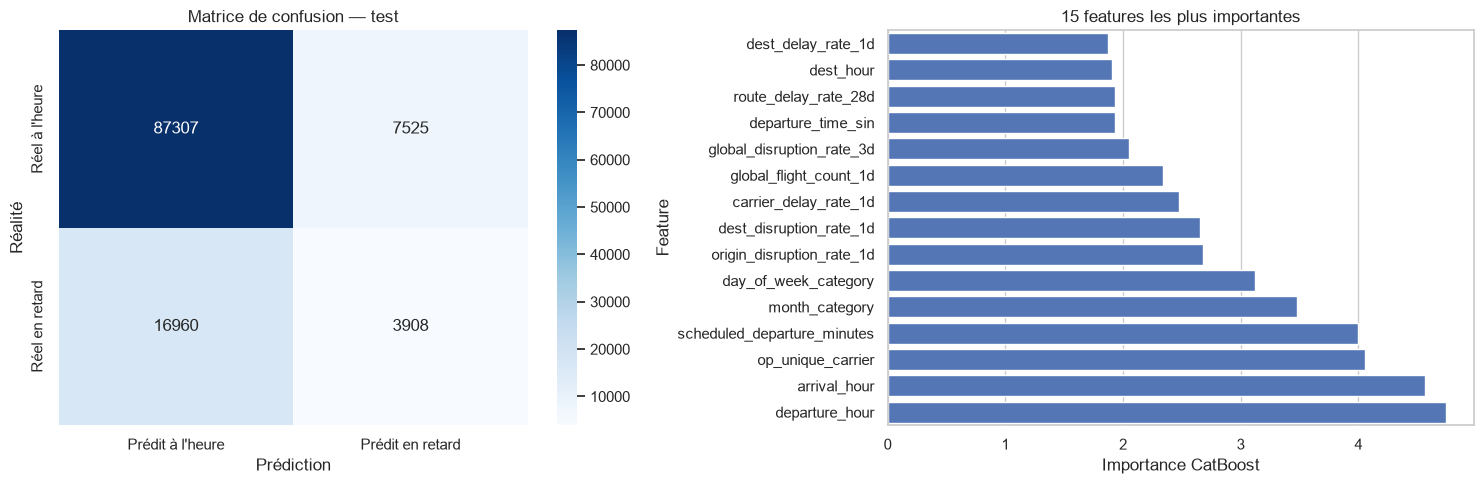

,feature,importance
0,departure_hour,4.744471
1,arrival_hour,4.562920
2,op_unique_carrier,4.055385
3,scheduled_departure_minutes,4.000092
4,month_category,3.477323
5,day_of_week_category,3.120205
6,origin_disruption_rate_1d,2.679325
7,dest_disruption_rate_1d,2.657180
8,carrier_delay_rate_1d,2.471121
9,global_flight_count_1d,2.340497


### Stabilité mensuelle du seuil global

,Mois,Précision,Rappel,Couverture,Alertes,Gate
0,Nov,30.1%,18.5%,9.0%,5170,Échoué
1,Déc,37.5%,18.9%,10.7%,6263,Échoué


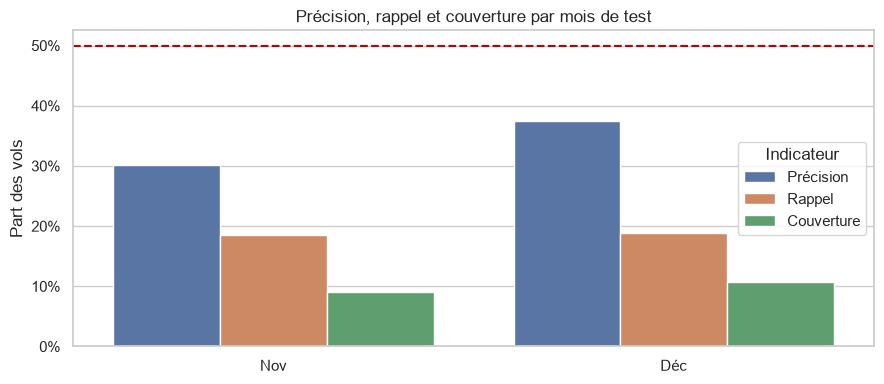

In [14]:
test_metrics = training_metrics["delay_classification"]["test"]
confusion = np.array(
    [
        [test_metrics["true_negative"], test_metrics["false_positive"]],
        [test_metrics["false_negative"], test_metrics["true_positive"]],
    ]
)

figure, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Prédit à l'heure", "Prédit en retard"],
    yticklabels=["Réel à l'heure", "Réel en retard"],
    ax=axes[0],
)
axes[0].set_title("Matrice de confusion — test")
axes[0].set_xlabel("Prédiction")
axes[0].set_ylabel("Réalité")

top_importance = feature_importance.head(15).sort_values("importance")
sns.barplot(data=top_importance, y="feature", x="importance", ax=axes[1], color="#4472C4")
axes[1].set_title("15 features les plus importantes")
axes[1].set_xlabel("Importance CatBoost")
axes[1].set_ylabel("Feature")
figure.tight_layout()
plt.show()

display(feature_importance.head(15))

monthly_performance = pd.DataFrame(
    [
        {
            "Mois": month_labels[int(month)],
            "Précision": values["precision"],
            "Rappel": values["recall"],
            "Couverture": values["alert_coverage"],
            "Alertes": values["alert_count"],
            "Gate": "Réussi" if business_gate["test_by_month"][month]["passed"] else "Échoué",
        }
        for month, values in training_metrics["delay_classification"]["test_by_month"].items()
    ]
)
display(Markdown("### Stabilité mensuelle du seuil global"), monthly_performance.style.format({
    "Précision": "{:.1%}", "Rappel": "{:.1%}", "Couverture": "{:.1%}"
}))
monthly_long = monthly_performance.melt(
    id_vars="Mois",
    value_vars=["Précision", "Rappel", "Couverture"],
    var_name="Indicateur",
    value_name="Valeur",
)
plt.figure(figsize=(9, 4))
sns.barplot(data=monthly_long, x="Mois", y="Valeur", hue="Indicateur")
plt.axhline(0.50, color="#C00000", linestyle="--", label="Objectif précision")
plt.gca().yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
plt.title("Précision, rappel et couverture par mois de test")
plt.ylabel("Part des vols")
plt.xlabel("")
plt.tight_layout()
plt.show()

### Comment lire les métriques ?

- **Précision** : parmi les alertes émises, proportion de vrais retards. Ce n'est pas l'exactitude globale, qui serait artificiellement élevée en répondant toujours « à l'heure ».
- **Borne basse à 95 %** : estimation prudente de la précision ou du rappel tenant compte du nombre d'observations. Le gate utilise cette borne et exige au moins 500 alertes.
- **Rappel** : parmi les vrais retards, proportion détectée.
- **Couverture** : part de tous les vols auxquels le site enverrait une alerte. Elle doit rester entre 5 et 10 %.
- **F1** : compromis entre précision et rappel.
- **ROC-AUC** : capacité du modèle à classer un vol retardé devant un vol à l'heure, indépendamment du seuil.
- **MAE** : erreur absolue moyenne de l'estimation en minutes.

Un gate échoué bloque toute alerte publiable. Les décisions, les minutes et les causes restent néanmoins consultables sous forme de diagnostics expérimentaux. La cause `security` est très rare et doit être interprétée avec prudence.

# Étape 4 — Visualisation et prédiction dans le notebook

L'interface actuelle est directement accessible dans Jupyter : graphiques de synthèse, explorateur filtrable et diagnostic d'un vol. Les graphiques statiques restent visibles sur GitHub ; les filtres deviennent interactifs après exécution du notebook. Une application Streamlit reste une évolution possible, mais elle devra respecter exactement le même blocage métier.

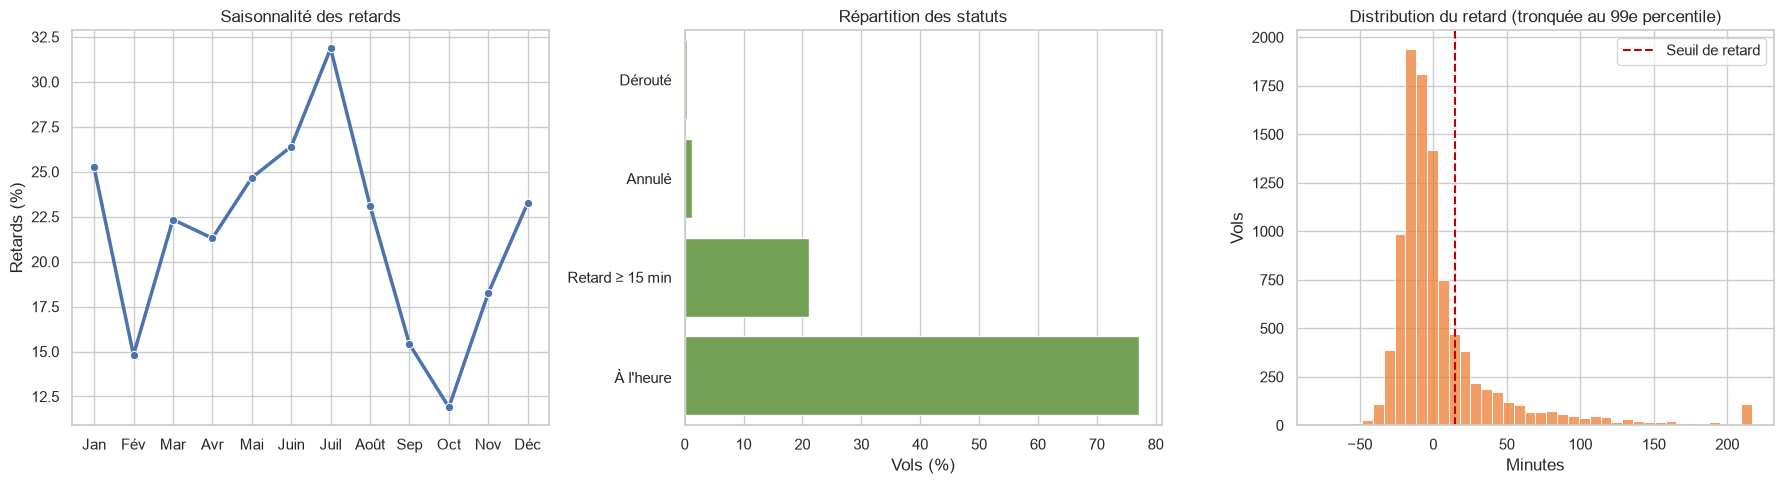

In [15]:
figure, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.lineplot(
    data=monthly_plot,
    x="Mois",
    y="delayed_flight_percentage",
    marker="o",
    linewidth=2.5,
    ax=axes[0],
)
axes[0].set(title="Saisonnalité des retards", xlabel="", ylabel="Retards (%)")

status_plot = status_metrics.copy()
status_plot["Statut"] = status_plot["flight_status"].map(
    {
        "on_time": "À l'heure",
        "delayed_15_plus": "Retard ≥ 15 min",
        "cancelled": "Annulé",
        "diverted": "Dérouté",
        "unknown": "Inconnu",
    }
)
status_plot = status_plot.sort_values("flight_percentage")
sns.barplot(data=status_plot, y="Statut", x="flight_percentage", ax=axes[1], color="#70AD47")
axes[1].set(title="Répartition des statuts", xlabel="Vols (%)", ylabel="")

completed_delays = flight_browser_data.loc[flight_browser_data["arr_delay"].notna(), "arr_delay"]
upper_bound = completed_delays.quantile(0.99)
sns.histplot(completed_delays.clip(upper=upper_bound), bins=40, ax=axes[2], color="#ED7D31")
axes[2].axvline(15, color="#C00000", linestyle="--", label="Seuil de retard")
axes[2].set(title="Distribution du retard (tronquée au 99e percentile)", xlabel="Minutes", ylabel="Vols")
axes[2].legend()

figure.tight_layout()
plt.show()

## Explorateur des 10 000 vols

Utiliser les menus pour filtrer les données propres par mois, compagnie, origine, destination et statut. Le tableau est limité au nombre de lignes choisi afin de rester lisible.

In [16]:
from ipywidgets import Dropdown, IntSlider, interact

def explore_flights(
    month: int,
    carrier: str,
    origin: str,
    destination: str,
    status: str,
    maximum_rows: int,
) -> None:
    filtered = flight_browser_data.copy()
    if month:
        filtered = filtered.loc[filtered["month"] == month]
    if carrier != "Toutes":
        filtered = filtered.loc[filtered["op_unique_carrier"] == carrier]
    if origin != "Toutes":
        filtered = filtered.loc[filtered["origin"] == origin]
    if destination != "Toutes":
        filtered = filtered.loc[filtered["dest"] == destination]
    if status != "Tous":
        filtered = filtered.loc[filtered["flight_status"] == status]
    print(f"{len(filtered):,} vol(s) correspondent aux filtres.")
    display(filtered.head(maximum_rows).reset_index(drop=True))

flight_explorer = interact(
    explore_flights,
    month=Dropdown(options=[("Tous", 0)] + [(month_labels[value], value) for value in range(1, 13)], description="Mois"),
    carrier=Dropdown(options=["Toutes"] + sorted(flight_browser_data["op_unique_carrier"].unique().tolist()), description="Compagnie"),
    origin=Dropdown(options=["Toutes"] + sorted(flight_browser_data["origin"].unique().tolist()), description="Origine"),
    destination=Dropdown(options=["Toutes"] + sorted(flight_browser_data["dest"].unique().tolist()), description="Destination"),
    status=Dropdown(options=["Tous", "on_time", "delayed_15_plus", "cancelled", "diverted"], description="Statut"),
    maximum_rows=IntSlider(value=20, min=5, max=100, step=5, description="Lignes"),
)

interactive(children=(Dropdown(description='Mois', options=(('Tous', 0), ('Jan', 1), ('Fév', 2), ('Mar', 3), (…

## Prédire un futur vol

Modifier les valeurs du dictionnaire ci-dessous, puis réexécuter les deux cellules. La date, le mois, le jour du mois et le jour de la semaine doivent être cohérents. Sans planning journalier complet, six profils typiques de congestion sont utilisés et le résultat reste un diagnostic non publiable.

In [17]:
flight_to_predict = {
    "flight_date": "2025-01-05",
    "month": 1,
    "day_of_month": 5,
    "day_of_week": 7,
    "op_unique_carrier": "AA",
    "op_carrier_fl_num": 100,
    "origin": "JFK",
    "origin_state_nm": "New York",
    "dest": "LAX",
    "dest_state_nm": "California",
    "crs_dep_time": 830,
    "crs_arr_time": 1145,
    "crs_elapsed_time": 375,
    "distance": 2475,
}
display(pd.Series(flight_to_predict, name="Vol à prédire"))

flight_date          2025-01-05
month                         1
day_of_month                  5
day_of_week                   7
op_unique_carrier            AA
op_carrier_fl_num           100
origin                      JFK
origin_state_nm        New York
dest                        LAX
dest_state_nm        California
crs_dep_time                830
crs_arr_time               1145
crs_elapsed_time            375
distance                   2475
Name: Vol à prédire, dtype: object

> ❌ **Aucune alerte publiable pour ce vol.**<br>- Aucun seuil ne respecte toutes les contraintes sur la validation.<br>- Les performances hors échantillon ne respectent pas toutes les contraintes métier.<br>- Les contraintes métier ne sont pas respectées pour chaque mois de test.<br>- Les six volumes du planning journalier exact ne sont pas fournis.

,Indicateur,Valeur
0,Statut de la prédiction,experimental_model_not_ready
1,Source de la congestion planifiée,typical_schedule_profile
2,Probabilité de retard,12.2 %
3,Seuil de classification,33.7 %
4,Décision expérimentale,Non
5,Alerte publiée,Non / bloquée
6,Estimation expérimentale si retard,40 min
7,Date du contexte historique,2024-12-31


,Cause,Probabilité conditionnelle (%),Cause retenue,Décision
0,Système aérien national,68.7,True,Retenue
1,Compagnie,57.1,True,Retenue
2,Météo,5.6,False,Non retenue
3,Sécurité,0.3,False,Non retenue


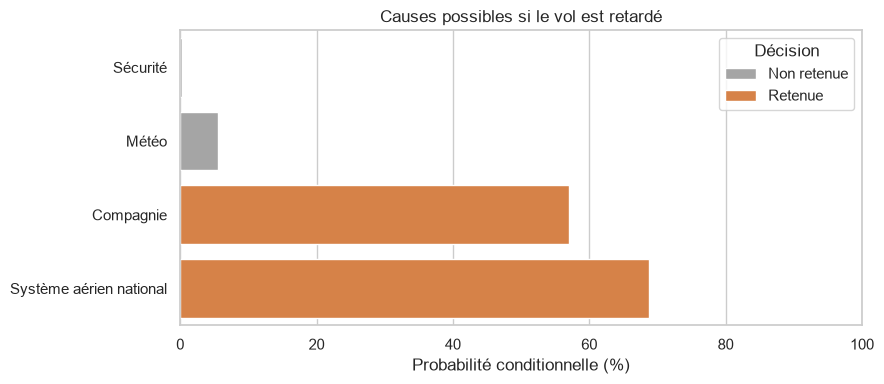

In [18]:
prediction = predict_flight(model_bundle, flight_to_predict)
if not prediction["prediction_publishable"]:
    blockers = "<br>".join(f"- {reason}" for reason in prediction["publication_blockers"])
    display(Markdown(f"> ❌ **Aucune alerte publiable pour ce vol.**<br>{blockers}"))

prediction_summary = pd.DataFrame(
    {
        "Indicateur": [
            "Statut de la prédiction",
            "Source de la congestion planifiée",
            "Probabilité de retard",
            "Seuil de classification",
            "Décision expérimentale",
            "Alerte publiée",
            "Estimation expérimentale si retard",
            "Date du contexte historique",
        ],
        "Valeur": [
            prediction["prediction_status"],
            prediction["schedule_context_source"],
            f"{prediction['delay_probability'] * 100:.1f} %",
            f"{prediction['classification_threshold'] * 100:.1f} %",
            "Oui" if prediction["diagnostic_is_delayed_15_prediction"] else "Non",
            "Oui" if prediction["published_delay_alert"] else "Non / bloquée",
            f"{prediction['diagnostic_estimated_delay_minutes_if_delayed']:.0f} min",
            prediction["historical_context_date"],
        ],
    }
)
reason_probabilities = pd.DataFrame(
    [
        {
            "Cause": reason_labels[reason],
            "Probabilité conditionnelle (%)": probability * 100,
            "Cause retenue": reason in prediction["diagnostic_predicted_reasons_if_delayed"],
        }
        for reason, probability in prediction["diagnostic_reason_probabilities_if_delayed"].items()
    ]
)
reason_probabilities["Décision"] = np.where(
    reason_probabilities["Cause retenue"], "Retenue", "Non retenue"
)

display(prediction_summary)
display(reason_probabilities.style.format({"Probabilité conditionnelle (%)": "{:.1f}"}))

plt.figure(figsize=(9, 4))
sns.barplot(
    data=reason_probabilities.sort_values("Probabilité conditionnelle (%)"),
    y="Cause",
    x="Probabilité conditionnelle (%)",
    hue="Décision",
    dodge=False,
    palette={"Retenue": "#ED7D31", "Non retenue": "#A5A5A5"},
)
plt.xlim(0, 100)
plt.title("Causes possibles si le vol est retardé")
plt.xlabel("Probabilité conditionnelle (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Conclusion

Le notebook permet maintenant de parcourir tout le pipeline dans l'ordre, de consulter les données propres, d'explorer les résultats Spark, de comprendre les métriques ML et de tester un diagnostic sans changer d'outil.

Sur le test temporel, le modèle émet 9,9 % d'alertes expérimentales avec 34,2 % de précision et 18,7 % de rappel. Il échoue donc au business gate et aucune alerte n'est publiable. Les prochains gains sérieux nécessitent la météo prévisionnelle, l'état opérationnel du jour et un holdout 2025 jamais consulté.